# 02 — Detailed EDA, CV audit, and adversarial validation

最初の submission 後に、データ生成単位・リーク経路・train/test drift を確認し、信頼する CV を決めます。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from kaggle_workflow.cv import group_overlap_by_fold, make_fold_assignments, passenger_groups
from kaggle_workflow.features import create_features
from kaggle_workflow.modeling import build_model, feature_importance, predict_probability

train = pd.read_csv(ROOT / "input/train.csv")
test = pd.read_csv(ROOT / "input/test.csv")
TARGET = "Transported"
SEED = 42

## Group structure and target consistency
PassengerId の `gggg` は旅行 group です。同一 group が学習・検証に跨ぐかを監査します。別コンペでは customer、patient、session、time など実際のデータ生成単位へ置き換えます。

In [2]:
groups = passenger_groups(train["PassengerId"])
group_stats = (
    train.assign(GroupId=groups)
    .groupby("GroupId")[TARGET]
    .agg(group_size="size", target_rate="mean", target_nunique="nunique")
)
display(group_stats.describe())
print("groups:", len(group_stats))
print("homogeneous observed groups:", int((group_stats["target_nunique"] == 1).sum()))

,group_size,target_rate,target_nunique
count,6217.000000,6217.000000,6217.000000
mean,1.398263,0.477140,1.128197
std,0.944051,0.468876,0.334336
min,1.000000,0.000000,1.000000
25%,1.000000,0.000000,1.000000
50%,1.000000,0.500000,1.000000
75%,1.000000,1.000000,1.000000
max,8.000000,1.000000,2.000000


groups: 6217
homogeneous observed groups: 5420


In [3]:
stratified_folds = make_fold_assignments(train, strategy="stratified", seed=SEED)
group_folds = make_fold_assignments(train, strategy="stratified_group", seed=SEED)
cv_audit = pd.DataFrame(
    {
        "fold": range(5),
        "ordinary_group_overlap": group_overlap_by_fold(train, stratified_folds),
        "group_cv_overlap": group_overlap_by_fold(train, group_folds),
        "ordinary_target_rate": [train.loc[stratified_folds == f, TARGET].mean() for f in range(5)],
        "group_cv_target_rate": [train.loc[group_folds == f, TARGET].mean() for f in range(5)],
    }
)
cv_audit

,fold,ordinary_group_overlap,group_cv_overlap,ordinary_target_rate,group_cv_target_rate
0,0,593,0,0.503738,0.503738
1,1,604,0,0.503738,0.503738
2,2,590,0,0.503738,0.503738
3,3,582,0,0.503452,0.503452
4,4,572,0,0.503452,0.503452


通常 split は同一 group を大量に共有するため、以後の比較では固定 `StratifiedGroupKFold` を使います。fold は CSV として保存し、全モデルの OOF 行を揃えます。

## Target relationships and missingness drift

In [4]:
categorical_columns = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
target_rates = pd.concat(
    [
        train.assign(value=train[column].astype("string").fillna("__MISSING__"))
        .groupby("value")[TARGET]
        .agg(["mean", "count"])
        .assign(feature=column)
        .reset_index()
        for column in categorical_columns
    ]
)
target_rates[["feature", "value", "mean", "count"]]

,feature,value,mean,count
0,HomePlanet,Earth,0.423946,4602
1,HomePlanet,Europa,0.658846,2131
2,HomePlanet,Mars,0.523024,1759
3,HomePlanet,__MISSING__,0.512438,201
0,CryoSleep,False,0.328921,5439
1,CryoSleep,True,0.817583,3037
2,CryoSleep,__MISSING__,0.488479,217
0,Destination,55 Cancri e,0.610000,1800
1,Destination,PSO J318.5-22,0.503769,796
2,Destination,TRAPPIST-1e,0.471175,5915


,train,test,absolute_gap
FoodCourt,0.021051,0.024784,0.003732
CryoSleep,0.024963,0.021744,0.003218
VRDeck,0.021627,0.018705,0.002922
HomePlanet,0.023122,0.020341,0.002781
Spa,0.021051,0.023615,0.002563
RoomService,0.020821,0.019172,0.001649
VIP,0.023352,0.021744,0.001608
Name,0.023007,0.021978,0.001029
ShoppingMall,0.023927,0.022913,0.001014
Age,0.020591,0.021277,0.000685


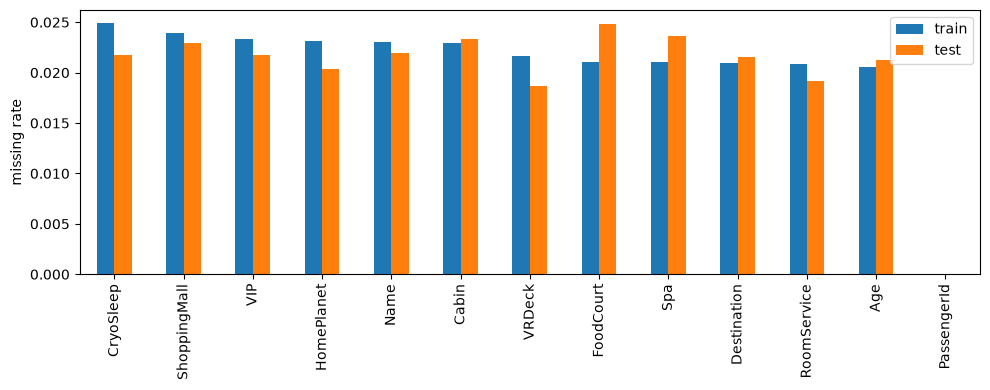

In [5]:
features = [column for column in test.columns]
missing_drift = pd.DataFrame(
    {
        "train": train[features].isna().mean(),
        "test": test[features].isna().mean(),
    }
)
missing_drift["absolute_gap"] = (missing_drift["train"] - missing_drift["test"]).abs()
display(missing_drift.sort_values("absolute_gap", ascending=False))
missing_drift[["train", "test"]].sort_values("train", ascending=False).plot.bar(figsize=(10, 4))
plt.ylabel("missing rate")
plt.tight_layout()
plt.show()

## Adversarial validation
train=0、test=1 を予測する OOF AUC を測ります。目的変数は使いません。AUC が高ければ分布差を識別できる特徴を確認し、その採否は group CV で決めます。

In [6]:
reference = pd.concat([train.drop(columns=TARGET), test], ignore_index=True)
av_features = create_features(reference, reference=reference, feature_set="full")
domain = np.r_[np.zeros(len(train), dtype=int), np.ones(len(test), dtype=int)]
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
av_oof = np.zeros(len(reference))
av_importances = []
for fold, (fit_idx, valid_idx) in enumerate(splitter.split(av_features, domain)):
    model = build_model("logistic", {"C": 0.08, "solver": "liblinear"}, SEED + fold, av_features)
    model.fit(av_features.iloc[fit_idx], domain[fit_idx])
    av_oof[valid_idx] = predict_probability(model, "logistic", av_features.iloc[valid_idx])
    importance = feature_importance(model, "logistic", av_features.columns.tolist())
    importance["fold"] = fold
    av_importances.append(importance)
av_auc = roc_auc_score(domain, av_oof)
av_importance = (
    pd.concat(av_importances).groupby("feature")["importance"].mean().sort_values(ascending=False)
)
print(f"adversarial validation OOF AUC: {av_auc:.4f}")
av_importance.head(20)

adversarial validation OOF AUC: 0.5052


feature
DestinationDeck_PSO J318.5-22_D    0.232051
RouteSide_?_TRAPPIST-1e_P          0.230274
DestinationDeck_TRAPPIST-1e_G      0.209376
DestinationDeck_?_G                0.196937
HomeDeck_Mars_D                    0.193015
VIP_True                           0.181115
AgeBand_senior                     0.166382
RouteSide_Europa_TRAPPIST-1e_S     0.161965
HomeDeck_Europa_A                  0.159364
CabinDeckSide_T_S                  0.156451
CryoSleep_False                    0.152419
HomeDeck_Earth_E                   0.142034
DestinationDeck_TRAPPIST-1e_?      0.139975
RouteSide_Mars_PSO J318.5-22_P     0.137659
AgeBand_young                      0.135891
Route_?_to_TRAPPIST-1e             0.134969
HomeDeck_Earth_?                   0.132678
Route_?_to_55 Cancri e             0.131379
CabinNumberBand_1                  0.130845
RouteSide_Earth_TRAPPIST-1e_?      0.130701
Name: importance, dtype: float64

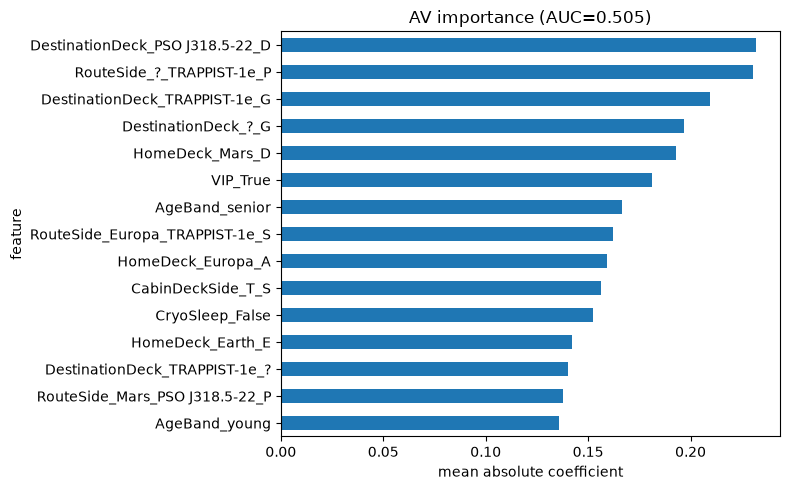

In [7]:
ax = (
    av_importance.head(15)
    .sort_values()
    .plot.barh(figsize=(8, 5), title=f"AV importance (AUC={av_auc:.3f})")
)
ax.set_xlabel("mean absolute coefficient")
plt.tight_layout()
plt.show()

## Decision
- 最初の ordinary StratifiedKFold は疎通確認専用。
- 以後は group overlap=0 の固定 fold で全モデルを比較。
- AV は診断専用で、特徴量・HPO・ensemble の選択は OOF に限定。
- HPO には seed の異なる専用 3-fold group CV、最終確認には固定 5-fold group CV を使い、同じ fold への過適合を少し緩和する。